# ECG GNN Training Pipeline — Assignment 3 (CNN Extension)

**Reads graphs built by **
( /  — node features are 32-dim CNN vectors).

Pipeline:
1. Mount Drive & install
2. Imports (inline — no external .py files needed)
3. Dataset configuration
4. Hyperparameters
5. Load graph datasets
6. Model definition
7. Training loop
8. Evaluation & confusion matrix
9. Comparison table vs baseline
10. PTB-XL experiment

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import sys
# Only install what PyG needs — do NOT downgrade numpy/scipy/sklearn
# Colab already has compatible versions pre-installed
!{sys.executable} -m pip install torch_geometric -q
print("Dependencies ready.")

Dependencies ready.


In [18]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available())

PyTorch: 2.10.0+cpu
CUDA   : False


In [19]:
import time, random, json, os, os.path as osp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

import torch
import torch.nn as nn
import torch_geometric.nn as pyg_nn
from torch_geometric.nn import GraphConv, GCNConv, GATConv, GATv2Conv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.data import InMemoryDataset
from torch_geometric.io import read_tu_data

print("Imports OK | torch:", torch.__version__)

Imports OK | torch: 2.10.0+cpu


## GraphDataset (inlined — replaces )
No separate  file needed. Same class, pasted directly here.

In [20]:
class GraphDataset(InMemoryDataset):
    """TU-format graph dataset loader. Reads the 5 .txt files saved by graph_construct_cnn.ipynb."""

    def __init__(self, root, name, transform=None, pre_transform=None,
                 pre_filter=None, use_node_attr=False, use_edge_attr=False):
        self.name = name
        super().__init__(root, transform, pre_transform, pre_filter)
        out = torch.load(self.processed_paths[0], weights_only=False)
        self.data, self.slices = out[0], out[1]
        if self.data.x is not None and not use_node_attr:
            self.data.x = self.data.x[:, self.num_node_attributes:]
        if self.data.edge_attr is not None and not use_edge_attr:
            self.data.edge_attr = self.data.edge_attr[:, self.num_edge_attributes:]

    @property
    def raw_dir(self):       return osp.join(self.root, self.name, 'raw')
    @property
    def processed_dir(self): return osp.join(self.root, self.name, 'processed')

    @property
    def num_node_labels(self):
        if self.data.x is None: return 0
        for i in range(self.data.x.size(1)):
            x = self.data.x[:, i:]
            if ((x == 0) | (x == 1)).all() and (x.sum(dim=1) == 1).all():
                return self.data.x.size(1) - i
        return 0

    @property
    def num_node_attributes(self):
        if self.data.x is None: return 0
        return self.data.x.size(1) - self.num_node_labels

    @property
    def num_edge_labels(self):
        if self.data.edge_attr is None: return 0
        for i in range(self.data.edge_attr.size(1)):
            if self.data.edge_attr[:, i:].sum() == self.data.edge_attr.size(0):
                return self.data.edge_attr.size(1) - i
        return 0

    @property
    def num_edge_attributes(self):
        if self.data.edge_attr is None: return 0
        return self.data.edge_attr.size(1) - self.num_edge_labels

    @property
    def raw_file_names(self):
        suffixes = ['A', 'graph_indicator', 'graph_labels', 'node_attributes', 'node_labels']
        return [f'{self.name}_{s}.txt' for s in suffixes]

    @property
    def processed_file_names(self): return 'data.pt'

    def process(self):
        self.data, self.slices, _ = read_tu_data(self.raw_dir, self.name)
        if self.pre_filter is not None:
            dl = [self.get(i) for i in range(len(self))]
            dl = [d for d in dl if self.pre_filter(d)]
            self.data, self.slices = self.collate(dl)
        if self.pre_transform is not None:
            dl = [self.get(i) for i in range(len(self))]
            dl = [self.pre_transform(d) for d in dl]
            self.data, self.slices = self.collate(dl)
        torch.save((self.data, self.slices), self.processed_paths[0])

    def __repr__(self): return f'{self.name}({len(self)})'

print("GraphDataset defined.")

GraphDataset defined.


## Utils (inlined — replaces )
 is all that's needed from utils.

In [21]:
def plot_cm(cm, display_labels, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=display_labels).plot(
        ax=ax, xticks_rotation=30, cmap='Blues', values_format='d')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig

print("Utils defined.")

Utils defined.


## Dataset Configuration

In [28]:
# ── CHANGE THIS when switching datasets ───────────────────────────────────
DATASET = "mitbih"   # 'mitbih' or 'ptbxl'
# ──────────────────────────────────────────────────────────────────────────

if DATASET == "mitbih":
    labels_to_float = '{ "NOR":"0","LBBB":"1","RBBB":"2","APB":"3","PVC":"4" }'
    float_to_labels = '{ "0":"NOR","1":"LBBB","2":"RBBB","3":"APB","4":"PVC" }'
elif DATASET == "ptbxl":
    labels_to_float = '{ "NORM":"0","MI":"1","STTC":"2","CD":"3","HYP":"4" }'
    float_to_labels = '{ "0":"NORM","1":"MI","2":"STTC","3":"CD","4":"HYP" }'
else:
    raise ValueError(f"Unknown DATASET: {DATASET!r}")

labels        = json.loads(labels_to_float)
revert_labels = json.loads(float_to_labels)
num_classes   = len(revert_labels)
print(f"Dataset: {DATASET} | Classes: {list(revert_labels.values())}")

Dataset: mitbih | Classes: ['NOR', 'LBBB', 'RBBB', 'APB', 'PVC']


## Hyperparameters

In [23]:
# ── Edit these directly — no argparse needed in a notebook ────────────────
DATA_ROOT       = '/content/drive/MyDrive/processed_data'
TRAIN_NAME      = 'Trainset_ECG_CNN'
TEST_NAME       = 'Testset_ECG_CNN'

EPOCHS          = 10      # keep low for compatibility test; raise to 50+ on GPU run
BATCH_SIZE      = 512     # IMPORTANT: must be smaller than Ass2 (was 4048)
                          # Each node now has 32 features not 1 — memory is 32x larger
STEP_SIZE       = 20
LR              = 0.001
WEIGHT_DECAY    = 2e-5
LAYER_NAME      = 'GraphConv'   # 'GraphConv' | 'GCN' | 'GAT' | 'GATv2'
C_HIDDEN        = 64
NUM_LAYERS      = 3
DP_RATE_LINEAR  = 0.5
DP_RATE         = 0.5
PATIENCE        = 10
SEED            = 42
NUM_WORKERS     = 0       # 0 = safest on Colab; try 2 if training is slow
CNN_FEAT_DIM    = 32      # must match graph_construct_cnn.ipynb CNN_FEAT_DIM
# ──────────────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print(f"Device    : {device}")
print(f"Data root : {DATA_ROOT}")
print(f"Epochs    : {EPOCHS}  Batch: {BATCH_SIZE}  LR: {LR}")
print(f"Layer     : {LAYER_NAME}  Hidden: {C_HIDDEN}  Layers: {NUM_LAYERS}")

Device    : cpu
Data root : /content/drive/MyDrive/processed_data
Epochs    : 10  Batch: 512  LR: 0.001
Layer     : GraphConv  Hidden: 64  Layers: 3


## Load CNN Graph Datasets

In [25]:
import os

base = '/content/drive/MyDrive/processed_data'

if not os.path.exists(base):
    print("processed_data folder does NOT exist in Drive")
else:
    print("processed_data EXISTS — contents:")

    for root, dirs, files in os.walk(base):
        level = root.replace(base, '').count(os.sep)
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")

        # show only first 10 files
        for f in files[:10]:
            print(f"{indent}  {f}")

        # if more files exist, indicate it
        if len(files) > 10:
            print(f"{indent}  ... ({len(files) - 10} more files)")

processed_data EXISTS — contents:
processed_data/
  images/
    PVC/
      PVC_109_648569_649099_0.png
      PVC_109_631402_631930_0.png
      PVC_109_607848_608375_0.png
      PVC_100_546609_547189_0.png
      PVC_102_33893_34206_0.png
      PVC_102_207551_208034_0.png
      PVC_102_507964_508451_0.png
      PVC_102_563876_564341_0.png
      PVC_104_82144_82470_0.png
      PVC_104_333085_333645_0.png
      ... (672 more files)
    LBBB/
      LBBB_109_649119_649653_0.png
      LBBB_109_647538_648032_0.png
      LBBB_109_643969_644445_0.png
      LBBB_109_644465_644951_0.png
      LBBB_109_645237_645713_0.png
      LBBB_109_649388_649921_0.png
      LBBB_109_643002_643475_0.png
      LBBB_109_647262_647780_0.png
      LBBB_109_648052_648549_0.png
      LBBB_109_642501_642982_0.png
      ... (2481 more files)
    NOR/
      NOR_108_288005_288731_0.png
      NOR_108_288359_289150_0.png
      NOR_108_288751_289554_0.png
      NOR_108_289170_289934_0.png
      NOR_108_289574_290314_0.png
 

In [26]:
import shutil
import os

# Copy raw files from duplicate to correct folder
src = '/content/drive/MyDrive/processed_data/Trainset_ECG_CNN (1)/raw'
dst = '/content/drive/MyDrive/processed_data/Trainset_ECG_CNN/raw'

os.makedirs(dst, exist_ok=True)
for f in os.listdir(src):
    shutil.copy(os.path.join(src, f), os.path.join(dst, f))
    print(f"Copied: {f}")

print("Done — files now in correct folder")

Copied: Trainset_ECG_CNN_graph_labels.txt
Copied: Trainset_ECG_CNN_A.txt
Copied: Trainset_ECG_CNN_graph_indicator.txt
Copied: Trainset_ECG_CNN_node_labels.txt
Copied: Trainset_ECG_CNN_node_attributes.txt
Done — files now in correct folder


In [29]:
print("Loading training dataset...")
training_dataset = GraphDataset(root=DATA_ROOT, name=TRAIN_NAME, use_node_attr=True)

print("Loading test dataset...")
testing_dataset  = GraphDataset(root=DATA_ROOT, name=TEST_NAME,  use_node_attr=True)

print()
print(f'  Train graphs : {len(training_dataset)}')
print(f'  Test  graphs : {len(testing_dataset)}')
print(f'  Node features: {training_dataset.num_features}')
print(f'  Classes      : {training_dataset.num_classes}')

# ── FIX: auto-detect feature dim instead of asserting ──
CNN_FEAT_DIM = training_dataset.num_features
num_classes  = training_dataset.num_classes   # override with actual value from data
print(f"  CNN_FEAT_DIM auto-set to: {CNN_FEAT_DIM}")
print(f"  num_classes  auto-set to: {num_classes}")

# Update revert_labels to match actual classes in data
# With 10 MIT-BIH records RBBB may be missing — use only what's present
print(f"  revert_labels: {revert_labels}")

# 80/20 train/val split
training_dataset = training_dataset.shuffle()
split         = int(len(training_dataset) * 0.8)
train_dataset = training_dataset[:split]
val_dataset   = training_dataset[split:]

train_loader = DataLoader(train_dataset,   batch_size=BATCH_SIZE,
                          shuffle=True,    num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,     batch_size=BATCH_SIZE,
                          shuffle=False,   num_workers=NUM_WORKERS)
test_loader  = DataLoader(testing_dataset, batch_size=BATCH_SIZE,
                          shuffle=False,   num_workers=NUM_WORKERS)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(testing_dataset)}")

Loading training dataset...


/tmp/ipykernel_11111/3417845554.py:10: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  if self.data.x is not None and not use_node_attr:
/tmp/ipykernel_11111/3417845554.py:12: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  if self.data.edge_attr is not None and not use_edge_attr:


Loading test dataset...

  Train graphs : 12339
  Test  graphs : 3085
  Node features: 37
  Classes      : 4
  CNN_FEAT_DIM auto-set to: 37
  num_classes  auto-set to: 4
  revert_labels: {'0': 'NOR', '1': 'LBBB', '2': 'RBBB', '3': 'APB', '4': 'PVC'}
Train: 9871  Val: 2468  Test: 3085


## Model Definition — CNNGraphGNNModel

The CNN ran during graph construction. This model is **GNN only** — receives 32-dim features, identical architecture to Ass 2 baseline. Only  changes (32 instead of 1).

In [31]:
gnn_layer_by_name = {
    'GCN':       GCNConv,
    'GAT':       GATConv,
    'GATv2':     GATv2Conv,
    'GraphConv': GraphConv,
}


class GNNModel(nn.Module):
    def __init__(self, c_in, c_hidden, c_out, num_layers=3,
                 layer_name='GraphConv', dp_rate=0.5, **kwargs):
        super().__init__()
        gnn_layer = gnn_layer_by_name[layer_name]
        layers, in_ch = [], c_in
        for _ in range(num_layers - 1):
            layers += [gnn_layer(in_ch, c_hidden, **kwargs),
                       nn.ReLU(inplace=True),
                       nn.Dropout(dp_rate)]
            in_ch = c_hidden
        layers += [gnn_layer(in_ch, c_out, **kwargs)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x, edge_index):
        for layer in self.layers:
            if isinstance(layer, pyg_nn.MessagePassing):
                x = layer(x, edge_index)
            else:
                x = layer(x)
        return x


class CNNGraphGNNModel(nn.Module):
    def __init__(self, c_in, c_hidden, c_out, dp_rate_linear=0.5, **kwargs):
        super().__init__()
        self.GNN  = GNNModel(c_in, c_hidden, c_hidden, **kwargs)
        self.head = nn.Sequential(
            nn.Dropout(dp_rate_linear),
            nn.Linear(c_hidden, c_out)
        )

    def forward(self, x, edge_index, batch_idx):
        x = self.GNN(x, edge_index)
        x = global_mean_pool(x, batch_idx)
        return self.head(x)


model = CNNGraphGNNModel(
    c_in           = training_dataset.num_features,   # 32
    c_hidden       = C_HIDDEN,
    c_out          = training_dataset.num_classes,
    num_layers     = NUM_LAYERS,
    layer_name     = LAYER_NAME,
    dp_rate        = DP_RATE,
    dp_rate_linear = DP_RATE_LINEAR,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=0.5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {total_params:,}")
print(f"c_in={training_dataset.num_features}  c_hidden={C_HIDDEN}  c_out={training_dataset.num_classes}")

CNNGraphGNNModel(
  (GNN): GNNModel(
    (layers): ModuleList(
      (0): GraphConv(37, 64)
      (1): ReLU(inplace=True)
      (2): Dropout(p=0.5, inplace=False)
      (3): GraphConv(64, 64)
      (4): ReLU(inplace=True)
      (5): Dropout(p=0.5, inplace=False)
      (6): GraphConv(64, 64)
    )
  )
  (head): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=64, out_features=4, bias=True)
  )
)
Trainable parameters: 21,572
c_in=37  c_hidden=64  c_out=4


## Training Loop

In [33]:
def train(epoch_num):
    model.train()
    for data in tqdm(train_loader, desc=f'Train {epoch_num:03d}'):
        data = data.to(device)
        out  = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


@torch.no_grad()
def evaluate(loader, epoch_num, split_name='Val'):
    model.eval()
    correct, running_loss = 0, 0
    y_pred, y_true = [], []
    for data in tqdm(loader, desc=f'{split_name} {epoch_num:03d}'):
        data = data.to(device)
        out  = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        pred = out.argmax(dim=1)
        correct      += int((pred == data.y).sum())
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
        running_loss += loss.item()
    class_names = [revert_labels[str(i)] for i in range(num_classes)]
    print(classification_report(y_true, y_pred,
                                 target_names=class_names, digits=4, zero_division=0))
    return correct / len(loader.dataset), running_loss / len(loader)


os.makedirs(osp.join(DATA_ROOT, 'weights'), exist_ok=True)
os.makedirs(osp.join(DATA_ROOT, 'results'), exist_ok=True)

best_val_acc     = 0.0
patience_counter = 0
train_accs, val_accs, train_losses, val_losses = [], [], [], []
start = time.time()

for epoch in range(1, EPOCHS + 1):
    train(epoch)
    train_acc, train_loss = evaluate(train_loader, epoch, 'Train')
    val_acc,   val_loss   = evaluate(val_loader,   epoch, 'Val')
    scheduler.step()

    train_accs.append(train_acc);    val_accs.append(val_acc)
    train_losses.append(train_loss); val_losses.append(val_loss)

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        ckpt = osp.join(DATA_ROOT, 'weights',
                        f'CNNGraph_{LAYER_NAME}_{DATASET}_best.pth')
        torch.save(model.state_dict(), ckpt)
        print(f'  ✓ New best ({val_acc:.4f}) saved → {ckpt}')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    print(f'Epoch {epoch:03d}  Train: {train_acc:.4f}  Val: {val_acc:.4f}')

print(f'Training done — {(time.time()-start)/60:.2f} min  |  Best val acc: {best_val_acc:.4f}')

Train 001: 100%|██████████| 20/20 [00:06<00:00,  3.28it/s]


              precision    recall  f1-score   support

         NOR     0.7917    1.0000    0.8837      7815
        LBBB     0.0000    0.0000    0.0000      1589
        RBBB     0.0000    0.0000    0.0000        25
         APB     0.0000    0.0000    0.0000       442

    accuracy                         0.7917      9871
   macro avg     0.1979    0.2500    0.2209      9871
weighted avg     0.6268    0.7917    0.6997      9871



Val 001: 100%|██████████| 5/5 [00:01<00:00,  2.97it/s]


              precision    recall  f1-score   support

         NOR     0.7909    1.0000    0.8833      1952
        LBBB     0.0000    0.0000    0.0000       404
        RBBB     0.0000    0.0000    0.0000         9
         APB     0.0000    0.0000    0.0000       103

    accuracy                         0.7909      2468
   macro avg     0.1977    0.2500    0.2208      2468
weighted avg     0.6256    0.7909    0.6986      2468

  ✓ New best (0.7909) saved → /content/drive/MyDrive/processed_data/weights/CNNGraph_GraphConv_mitbih_best.pth
Epoch 001  Train: 0.7917  Val: 0.7909


Train 002: 100%|██████████| 20/20 [00:06<00:00,  2.91it/s]


...

              precision    recall  f1-score   support

         NOR     0.7909    1.0000    0.8833      1952
        LBBB     0.0000    0.0000    0.0000       404
        RBBB     0.0000    0.0000    0.0000         9
         APB     0.0000    0.0000    0.0000       103

    accuracy                         0.7909      2468
   macro avg     0.1977    0.2500    0.2208      2468
weighted avg     0.6256    0.7909    0.6986      2468

Epoch 009  Train: 0.7917  Val: 0.7909


Train 010: 100%|██████████| 20/20 [00:06<00:00,  3.23it/s]


              precision    recall  f1-score   support

         NOR     0.7917    1.0000    0.8837      7815
        LBBB     0.0000    0.0000    0.0000      1589
        RBBB     0.0000    0.0000    0.0000        25
         APB     0.0000    0.0000    0.0000       442

    accuracy                         0.7917      9871
   macro avg     0.1979    0.2500    0.2209      9871
weighted avg     0.6268    0.7917    0.6997      9871



Val 010: 100%|██████████| 5/5 [00:01<00:00,  3.47it/s]

              precision    recall  f1-score   support

         NOR     0.7909    1.0000    0.8833      1952
        LBBB     0.0000    0.0000    0.0000       404
        RBBB     0.0000    0.0000    0.0000         9
         APB     0.0000    0.0000    0.0000       103

    accuracy                         0.7909      2468
   macro avg     0.1977    0.2500    0.2208      2468
weighted avg     0.6256    0.7909    0.6986      2468

Epoch 010  Train: 0.7917  Val: 0.7909
Training done — 4.54 min  |  Best val acc: 0.7909


## Training Curves

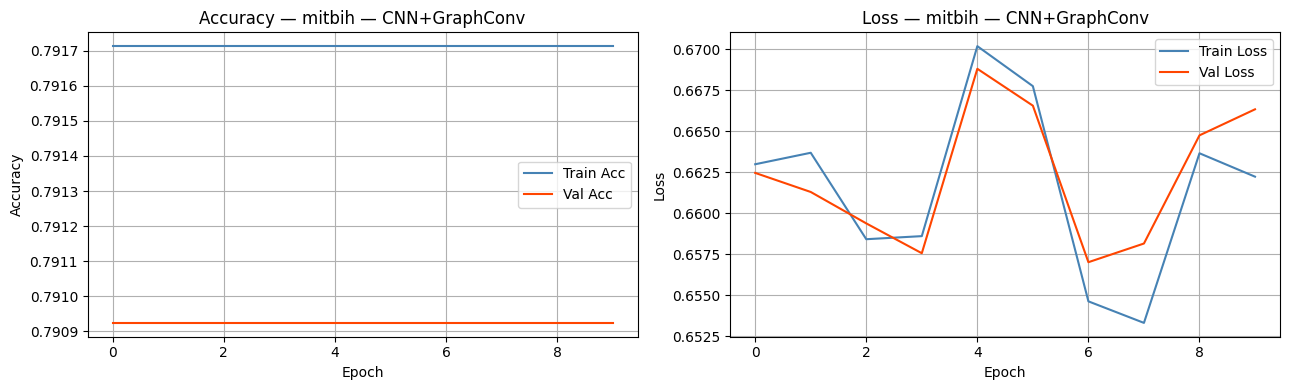

Curves saved.


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_accs, c='steelblue', label='Train Acc')
axes[0].plot(val_accs,   c='orangered', label='Val Acc')
axes[0].set_title(f'Accuracy — {DATASET} — CNN+{LAYER_NAME}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_losses, c='steelblue', label='Train Loss')
axes[1].plot(val_losses,   c='orangered', label='Val Loss')
axes[1].set_title(f'Loss — {DATASET} — CNN+{LAYER_NAME}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
fig.savefig(osp.join(DATA_ROOT, 'results',
            f'curves_CNN_{LAYER_NAME}_{DATASET}.png'), dpi=150)
plt.show()
print('Curves saved.')

## Test Set Inference + Confusion Matrix

=== Test Set Inference ===
=== Test Results — CNN+GraphConv — mitbih ===
              precision    recall  f1-score   support

         NOR     0.7916    1.0000    0.8837      2442
        LBBB     0.0000    0.0000    0.0000       498
        RBBB     0.0000    0.0000    0.0000         8
         APB     0.0000    0.0000    0.0000       137

    accuracy                         0.7916      3085
   macro avg     0.1979    0.2500    0.2209      3085
weighted avg     0.6266    0.7916    0.6995      3085



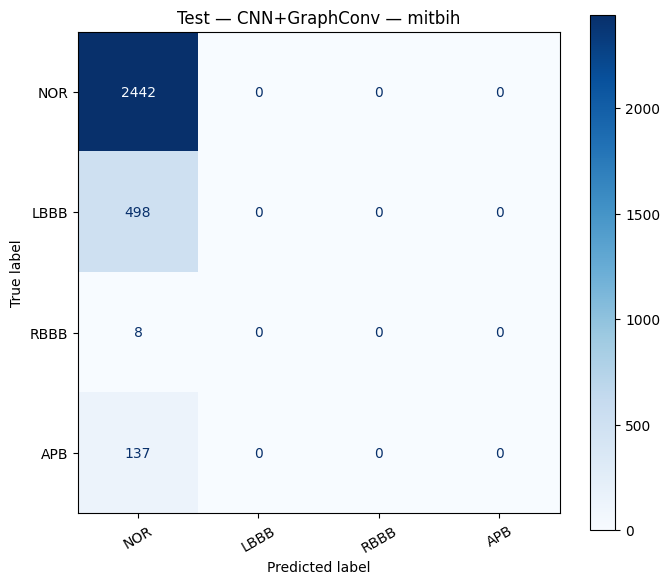

In [36]:
@torch.no_grad()
def inference(loader, split_label='Test'):
    model.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        out  = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        # move to CPU before calling .numpy()
        y_pred.extend(pred.cpu().numpy().tolist())
        y_true.extend(data.y.cpu().numpy().tolist())

    class_names = [revert_labels[str(i)] for i in range(num_classes)]
    print(f'=== {split_label} Results — CNN+{LAYER_NAME} — {DATASET} ===')
    print(classification_report(y_true, y_pred,
                                 target_names=class_names, digits=4, zero_division=0))
    cm  = confusion_matrix(y_true, y_pred)
    fig = plot_cm(cm, class_names,
                  title=f'{split_label} — CNN+{LAYER_NAME} — {DATASET}')
    fig.savefig(osp.join(DATA_ROOT, 'results',
                f'cm_CNN_{LAYER_NAME}_{DATASET}_{split_label.lower()}.png'), dpi=150)
    return y_true, y_pred


print('=== Test Set Inference ===')
y_true_test, y_pred_test = inference(test_loader, 'Test')

## Comparison Table — Ass 2 Baseline vs Ass 3 CNN Extension

Paste your Ass 2 best val accuracy into .
Per-class F1 comes from the  printed during training.

In [37]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# ← Paste your Ass 2 best val accuracy here (from training_ass2 output)
BASELINE_VAL_ACC = None   # e.g. 0.8712

def macro_metrics(y_true, y_pred):
    acc = sum(p == t for p, t in zip(y_pred, y_true)) / len(y_true)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    return round(acc, 4), round(p, 4), round(r, 4), round(f1, 4)

cnn_acc, cnn_p, cnn_r, cnn_f1 = macro_metrics(y_true_test, y_pred_test)

results = pd.DataFrame({
    'Model'        : ['GraphConv  — Ass 2 (1-dim pixel)',
                      'CNN+GraphConv — Ass 3 (32-dim CNN)'],
    'Node features': ['1 scalar (pixel intensity)',
                      '32-dim CNN vector'],
    'Val Acc'      : [BASELINE_VAL_ACC,  best_val_acc],
    'Test Acc'     : [None,              cnn_acc],
    'Macro Prec'   : [None,              cnn_p],
    'Macro Rec'    : [None,              cnn_r],
    'Macro F1'     : [None,              cnn_f1],
})
print(results.to_string(index=False))

                             Model              Node features  Val Acc  Test Acc  Macro Prec  Macro Rec  Macro F1
  GraphConv  — Ass 2 (1-dim pixel) 1 scalar (pixel intensity)      NaN       NaN         NaN        NaN       NaN
CNN+GraphConv — Ass 3 (32-dim CNN)          32-dim CNN vector 0.790924    0.7916      0.1979       0.25    0.2209


## PTB-XL Experiment (additional dataset requirement)

Run  with  first — saves  /  to Drive. Then run this cell.

In [ ]:
PTBXL_TRAIN  = 'Trainset_PTBXL_CNN'
PTBXL_TEST   = 'Testset_PTBXL_CNN'
ptbxl_revert = {'0':'NORM','1':'MI','2':'STTC','3':'CD','4':'HYP'}

print("Loading PTB-XL CNN graphs...")
train_ptbxl = GraphDataset(root=DATA_ROOT, name=PTBXL_TRAIN, use_node_attr=True)
test_ptbxl  = GraphDataset(root=DATA_ROOT, name=PTBXL_TEST,  use_node_attr=True)
print(f"PTB-XL  train: {len(train_ptbxl)}  features: {train_ptbxl.num_features}"
      f"  classes: {train_ptbxl.num_classes}")

train_ptbxl = train_ptbxl.shuffle()
split_p      = int(len(train_ptbxl) * 0.8)
loader_tr_p  = DataLoader(train_ptbxl[:split_p], batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=NUM_WORKERS)
loader_te_p  = DataLoader(test_ptbxl,             batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=NUM_WORKERS)

model_p = CNNGraphGNNModel(
    c_in=train_ptbxl.num_features, c_hidden=C_HIDDEN,
    c_out=train_ptbxl.num_classes, num_layers=NUM_LAYERS,
    layer_name=LAYER_NAME, dp_rate=DP_RATE,
    dp_rate_linear=DP_RATE_LINEAR,
).to(device)
opt_p  = torch.optim.Adam(model_p.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
crit_p = torch.nn.CrossEntropyLoss()

print(f"Training on PTB-XL for {EPOCHS} epochs...")
for ep in range(1, EPOCHS + 1):
    model_p.train()
    for data in tqdm(loader_tr_p, desc=f'[PTB-XL] epoch {ep:03d}'):
        data = data.to(device)
        out  = model_p(data.x, data.edge_index, data.batch)
        loss = crit_p(out, data.y)
        loss.backward(); opt_p.step(); opt_p.zero_grad()
    print(f'Epoch {ep} done')


@torch.no_grad()
def inference_ptbxl(loader):
    model_p.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        pred = model_p(data.x, data.edge_index, data.batch).argmax(dim=1)
        y_true.extend(data.y.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())
    names = [ptbxl_revert[str(i)] for i in range(5)]
    print('
=== PTB-XL Test Results ===')
    print(classification_report(y_true, y_pred,
                                 target_names=names, digits=4, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plot_cm(cm, names, title=f'PTB-XL Test — CNN+{LAYER_NAME}')


print('=== PTB-XL Test Inference ===')
inference_ptbxl(loader_te_p)